In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [ ]:
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

print(movies.shape, credits.shape)

# credits has its own 'title' column, so drop it before merging
df = movies.merge(credits.drop(columns='title'), left_on='id', right_on='movie_id')
df = df.drop(columns='movie_id')

print(df.shape)
df.head(2)

(4803, 20) (4803, 4)
(4803, 22)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


In [ ]:
df.info()
print(df.isnull().sum()[df.isnull().sum() > 0])
print("Duplicate titles:", df['title'].duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [ ]:
def safe_parse(x):
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []

def get_names(x, n=None):
    names = [d['name'] for d in safe_parse(x)]
    return names[:n] if n else names

def get_director(x):
    for d in safe_parse(x):
        if d.get('job') == 'Director':
            return d['name']
    return ''

df['genres_list']   = df['genres'].apply(get_names)
df['keywords_list'] = df['keywords'].apply(get_names)
df['cast_list']     = df['cast'].apply(lambda x: get_names(x, 3))   # top 3 actors
df['director']      = df['crew'].apply(get_director)

df[['title', 'genres_list', 'keywords_list', 'cast_list', 'director']].head()

,title,genres_list,keywords_list,cast_list,director
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",James Cameron
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]",Gore Verbinski
2,Spectre,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]",Sam Mendes
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]",Christopher Nolan
4,John Carter,"[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",Andrew Stanton


In [ ]:
def clean_names(x):
    if isinstance(x, list):
        return [i.replace(" ", "").lower() for i in x]
    if isinstance(x, str):
        return x.replace(" ", "").lower()
    return ''

for col in ['keywords_list', 'cast_list']:
    df[col] = df[col].apply(clean_names)
df['director_clean'] = df['director'].apply(clean_names)

df['overview'] = df['overview'].fillna('')
df['tagline']  = df['tagline'].fillna('')

In [ ]:
def create_soup(row):
    return ' '.join([
        ' '.join(row['keywords_list']),
        ' '.join(row['cast_list']),
        (row['director_clean'] + ' ') * 2,   # weight director x2
        row['overview'].lower(),
        row['tagline'].lower()
    ])

df['soup'] = df.apply(create_soup, axis=1)
df['soup'].iloc[0][:300]

'cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d samworthington zoesaldana sigourneyweaver jamescameron jamescameron  in the 22nd century, a paraplegic marine is di'

In [ ]:
tfidf = TfidfVectorizer(stop_words='english', min_df=2, ngram_range=(1, 2), max_features=50000)
tfidf_matrix = tfidf.fit_transform(df['soup'])
print("TF-IDF matrix:", tfidf_matrix.shape)

# TF-IDF vectors are L2-normalised, so linear_kernel == cosine similarity (and faster)
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
print("Similarity matrix:", cosine_sim.shape)

TF-IDF matrix: (4803, 28159)
Similarity matrix: (4803, 4803)


In [ ]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

def recommend(title, k=10):
    if title not in indices:
        return f"'{title}' not found in dataset."
    idx = indices[title]
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:k+1]
    rec_idx = [i for i, _ in scores]
    out = df.iloc[rec_idx][['title', 'genres_list', 'vote_average']].copy()
    out['similarity'] = [round(s, 3) for _, s in scores]
    return out

recommend('The Dark Knight Rises')

,title,genres_list,vote_average,similarity
65,The Dark Knight,"[Drama, Action, Crime, Thriller]",8.2,0.418
428,Batman Returns,"[Action, Fantasy]",6.6,0.297
119,Batman Begins,"[Action, Crime, Drama]",7.5,0.288
299,Batman Forever,"[Action, Crime, Fantasy]",5.2,0.269
1359,Batman,"[Fantasy, Action]",7.0,0.183
3854,"Batman: The Dark Knight Returns, Part 2","[Action, Animation]",7.9,0.161
1196,The Prestige,"[Drama, Mystery, Thriller]",8.0,0.139
9,Batman v Superman: Dawn of Justice,"[Action, Adventure, Fantasy]",5.7,0.133
210,Batman & Robin,"[Action, Crime, Fantasy]",4.2,0.128
2507,Slow Burn,"[Mystery, Crime, Drama, Thriller]",5.5,0.123


In [ ]:
knn = NearestNeighbors(metric='cosine', algorithm='brute')
knn.fit(tfidf_matrix)

def recommend_knn(title, k=10):
    idx = indices[title]
    dist, ind = knn.kneighbors(tfidf_matrix[idx], n_neighbors=k+1)
    rec_idx = [i for i in ind[0] if i != idx][:k]
    return df.iloc[rec_idx][['title', 'genres_list', 'vote_average']]

recommend_knn('Avatar')

,title,genres_list,vote_average
2403,Aliens,"[Horror, Action, Thriller, Science Fiction]",7.7
282,True Lies,"[Action, Thriller]",6.8
279,Terminator 2: Judgment Day,"[Action, Thriller, Science Fiction]",7.7
3439,The Terminator,"[Action, Thriller, Science Fiction]",7.3
587,The Abyss,"[Adventure, Action, Thriller, Science Fiction]",7.1
47,Star Trek Into Darkness,"[Action, Adventure, Science Fiction]",7.4
3604,Apollo 18,"[Horror, Thriller, Science Fiction]",5.0
1341,The Inhabited Island,"[Action, Fantasy, Science Fiction, Thriller]",5.3
369,Lara Croft Tomb Raider: The Cradle of Life,"[Action, Adventure, Fantasy, Thriller]",5.5
582,Battle: Los Angeles,"[Action, Science Fiction]",5.5


In [ ]:
K = 10
genre_sets = df['genres_list'].apply(set).tolist()

# Sample 1000 query movies that have at least one genre
rng = np.random.default_rng(42)
valid = [i for i, g in enumerate(genre_sets) if len(g) > 0]
query_idx = rng.choice(valid, size=1000, replace=False)

def evaluate(query_idx, rec_matrix):
    prec, jac = [], []
    for q, recs in zip(query_idx, rec_matrix):
        gq = genre_sets[q]
        prec.append(np.mean([len(gq & genre_sets[r]) > 0 for r in recs]))
        jac.append(np.mean([len(gq & genre_sets[r]) / len(gq | genre_sets[r]) for r in recs]))
    coverage = len(set(np.ravel(rec_matrix))) / len(df)
    return {'Precision@K': np.mean(prec), 'Mean Jaccard': np.mean(jac), 'Coverage': coverage}

# --- Model A: TF-IDF + cosine ---
sim = linear_kernel(tfidf_matrix[query_idx], tfidf_matrix)
sim[np.arange(len(query_idx)), query_idx] = -1          # exclude the movie itself
recs_cosine = np.argsort(-sim, axis=1)[:, :K]

# --- Model B: NearestNeighbors ---
_, ind = knn.kneighbors(tfidf_matrix[query_idx], n_neighbors=K+1)
recs_knn = np.array([[i for i in row if i != q][:K] for q, row in zip(query_idx, ind)])

# --- Baseline: random recommendations ---
recs_random = rng.integers(0, len(df), size=(len(query_idx), K))

results = pd.DataFrame({
    'TF-IDF + Cosine': evaluate(query_idx, recs_cosine),
    'NearestNeighbors': evaluate(query_idx, recs_knn),
    'Random baseline': evaluate(query_idx, recs_random),
}).T

print(results.round(3))

                  Precision@K  Mean Jaccard  Coverage
TF-IDF + Cosine         0.709         0.313     0.835
NearestNeighbors        0.709         0.313     0.835
Random baseline         0.490         0.163     0.877


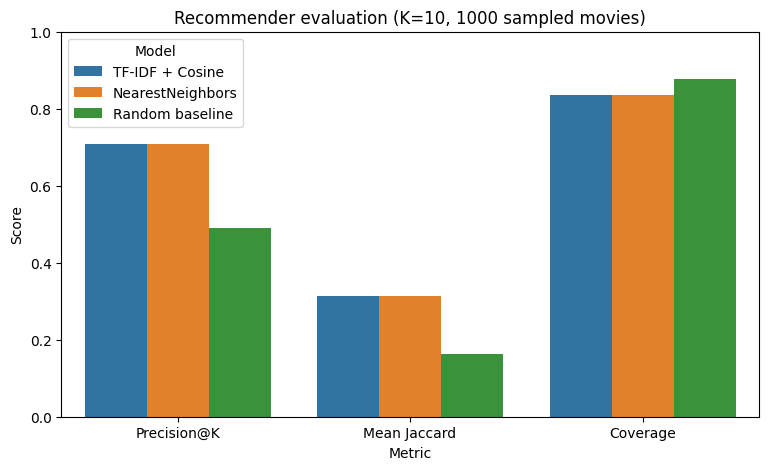

In [ ]:
results_plot = results.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')

plt.figure(figsize=(9, 5))
sns.barplot(data=results_plot, x='Metric', y='Score', hue='index')
plt.title(f'Recommender evaluation (K={K}, 1000 sampled movies)')
plt.ylim(0, 1)
plt.legend(title='Model')
plt.show()

In [ ]:
def build_and_eval(text_series, name):
    m = TfidfVectorizer(stop_words='english', min_df=2).fit_transform(text_series)
    s = linear_kernel(m[query_idx], m)
    s[np.arange(len(query_idx)), query_idx] = -1
    r = np.argsort(-s, axis=1)[:, :K]
    return name, evaluate(query_idx, r)

experiments = [
    build_and_eval(df['overview'].str.lower(), 'Overview only'),
    build_and_eval(df['keywords_list'].apply(' '.join), 'Keywords only'),
    build_and_eval(df['cast_list'].apply(' '.join) + ' ' + df['director_clean'], 'Cast + Director'),
    build_and_eval(df['soup'], 'Full soup'),
]
ablation = pd.DataFrame({n: r for n, r in experiments}).T
print(ablation.round(3))

                 Precision@K  Mean Jaccard  Coverage
Overview only          0.651         0.270     0.801
Keywords only          0.675         0.287     0.671
Cast + Director        0.633         0.252     0.708
Full soup              0.712         0.313     0.824


In [ ]:
import joblib

# Save the TF-IDF vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
print("TF-IDF vectorizer saved as 'tfidf_vectorizer.joblib'")

# Save the KNN model
joblib.dump(knn, 'knn_model.joblib')
print("KNN model saved as 'knn_model.joblib'")

TF-IDF vectorizer saved as 'tfidf_vectorizer.joblib'
KNN model saved as 'knn_model.joblib'


In [ ]:
import joblib

# Combine the TF-IDF vectorizer and KNN model into a dictionary
model_package = {
    'tfidf_vectorizer': tfidf,
    'knn_model': knn
}

# Save the dictionary to a single .pkl file
joblib.dump(model_package, 'movie_recommendation_models.pkl')
print("TF-IDF vectorizer and KNN model saved to 'movie_recommendation_models.pkl'")

TF-IDF vectorizer and KNN model saved to 'movie_recommendation_models.pkl'
